# Прогнозирование временных рядов: ML и продвинутые методы


**Содержание:**

1. **Валидация** - скользящая (walk-forward) и кросс-валидация по времени.
2. **Данные** - загрузка индекса Мосбиржи, расчёт лог-доходностей.
3. **Инжиниринг признаков** - лаги, скользящие средние, волатильность, RSI, MACD, объём, календарные и статистические признаки.
4. **Модели** - градиентный бустинг (LightGBM), SVR, LSTM, AutoARIMA.
5. **Сравнение** - честное сравнение по 1-step-ahead RMSE.

**Важно:** для временных рядов разбиение train/val/test делается по времени (без перемешивания). Прогнозы сравниваются на одном шаге вперёд.






## Методы валидации моделей

Очень распространённый подход к оценке качества моделей называется **кросс-валидация**.

Она особенно полезна в двух случаях:

1. Когда нужно подобрать гиперпараметры модели.
2. Когда нужно выбрать лучшую модель из нескольких альтернатив.

### Что такое кросс-валидация

**Кросс-валидация** - это метод оценки качества модели, который позволяет получить более надёжную оценку её способности обобщать данные, то есть работать на новых наблюдениях.

Идея проста:
мы несколько раз делим данные на обучающую и тестовую выборки, обучаем модель и измеряем её качество. В результате получаем не одну оценку ошибки, а несколько, что делает итоговую оценку более устойчивой.

Это особенно важно при небольших объёмах данных, где случайное разбиение может сильно повлиять на результат.

---

## Почему обычная k-fold кросс-валидация не подходит для временных рядов

В классической **k-fold кросс-валидации**:

* данные случайным образом разбиваются на k частей,
* каждая часть по очереди используется как тестовая,
* остальные части используются для обучения.

Проблема в том, что такое разбиение **нарушает временной порядок наблюдений**.

Для временных рядов это недопустимо, потому что:

* модель не должна видеть будущее при обучении,
* нельзя использовать данные из 2023 года для предсказания 2021 года.

Это создаёт утечку информации и приводит к завышенной оценке качества модели.

---

## Как правильно валидировать модели для временных рядов

Для временных рядов используют **разбиение по времени**:

* обучающая выборка - это прошлое,
* тестовая выборка - это будущее.

Пример:

* train: 2015–2019
* test: 2020

или схема с расширяющимся окном:

* train: 2015
* test: 2016
* train: 2015–2016
* test: 2017
* и так далее.

Такой подход корректно имитирует реальную задачу прогнозирования.



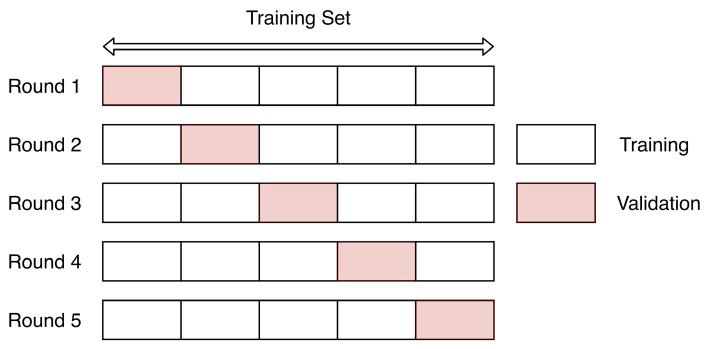







## Скользящая (walk-forward) валидация






При walk-forward валидации модель обучается на прошлых данных и проверяется на следующих по времени. Так мы имитируем реальный сценарий прогноза (не используем будущее при обучении).



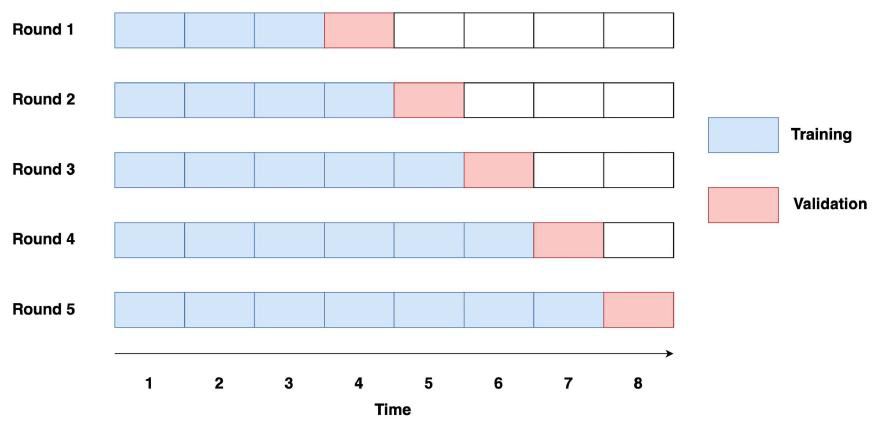






## Скользящая (walk-forward) валидация with a sliding window






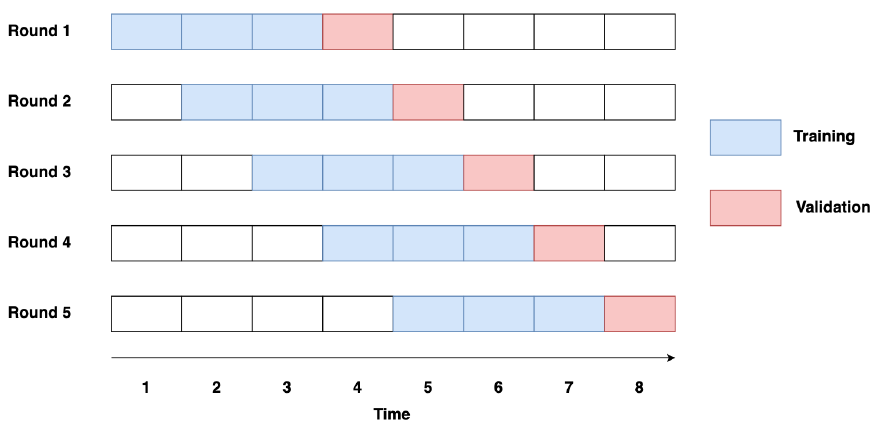






## Реализация






In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
# !pip install apimoex


In [2]:
import apimoex
import requests
from datetime import date

In [3]:
# moex_utils.py

import requests
import apimoex
import pandas as pd
from datetime import datetime
import moex_utils as moex

In [59]:
today = date.today()
df = moex.get_moex_index("MCFTRN", start = '2010-01-01', end = today)
df.index = pd.DatetimeIndex(df.index).to_period('D')
df.tail()

,BOARDID,close,VOLUME,volume
date,,,,
2026-02-10,RTSI,6305.01,2.389374e+09,5.225669e+10
2026-02-11,RTSI,6399.48,3.360821e+09,7.070704e+10
2026-02-12,RTSI,6417.84,1.494536e+09,4.471251e+10
2026-02-13,RTSI,6442.62,2.816985e+09,7.941874e+10
2026-02-16,RTSI,6457.15,1.706318e+09,5.973054e+10


In [60]:
df['log_rtns'] = np.log(df['close']) - np.log(df['close'].shift(1))

In [61]:
df.drop(columns=['close'], inplace=True)
df.drop(columns=['BOARDID'], inplace=True)
df.drop(columns=['VOLUME'], inplace=True)

In [62]:
df

,volume,log_rtns
date,,
2010-01-11,0.000000e+00,NaN
2010-01-12,0.000000e+00,-0.011917
2010-01-13,0.000000e+00,0.005129
2010-01-14,0.000000e+00,0.014282
2010-01-15,0.000000e+00,-0.002046
...,...,...
2026-02-10,5.225669e+10,-0.003161
2026-02-11,7.070704e+10,0.014872
2026-02-12,4.471251e+10,0.002865


<Axes: xlabel='date'>

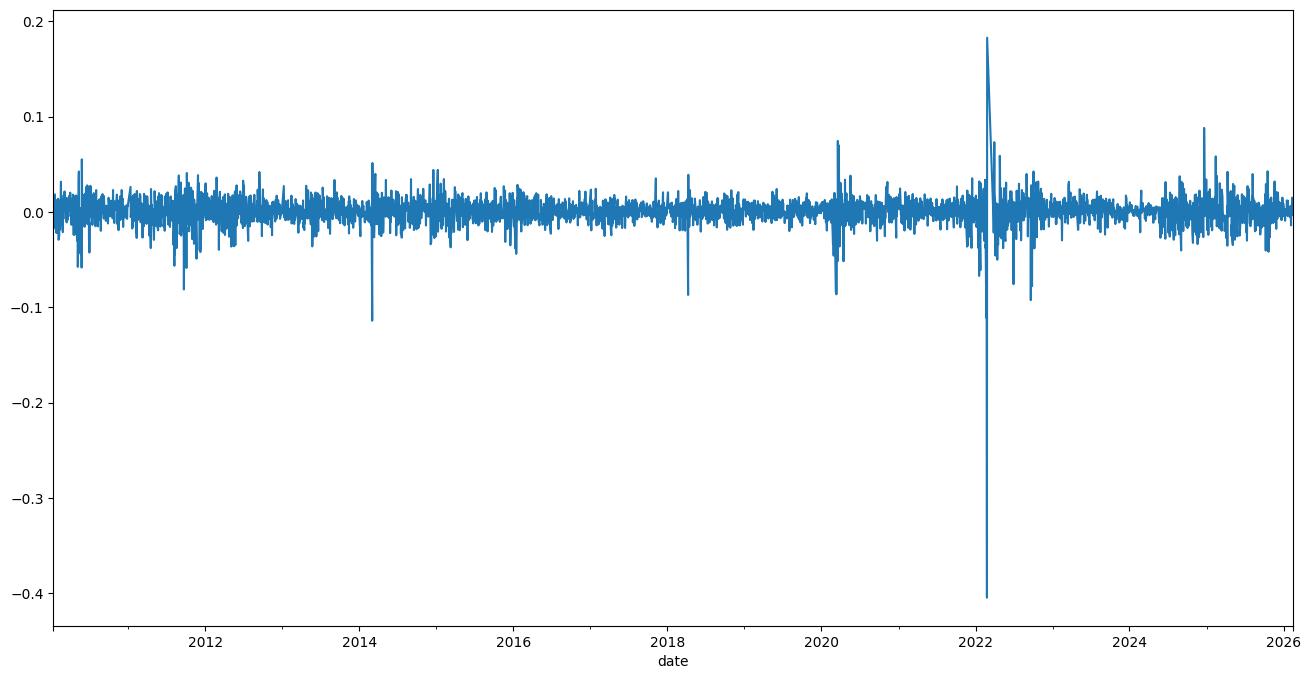

In [8]:
df['log_rtns'].plot(figsize=(16,8))

In [9]:
X = df.copy()
y = X.pop("log_rtns")

**Расширяющееся окно (expanding window) walk-forward валидация.** Обучающая выборка каждый раз расширяется (все прошлые данные), тестовое окно сдвигается вперёд. Ниже задаём разбиение и выводим индексы границ фолдов.






In [53]:
expanding_cv = TimeSeriesSplit(n_splits=5, test_size=12)

for fold, (train_ind, valid_ind) in enumerate(expanding_cv.split(X)):
  print(f"Fold {fold} ----")
  print(f"Train indices: {train_ind}")
  print(f"Valid indices: {valid_ind}")

Fold 0 ----
Train indices: [   0    1    2 ... 3980 3981 3982]
Valid indices: [3983 3984 3985 3986 3987 3988 3989 3990 3991 3992 3993 3994]
Fold 1 ----
Train indices: [   0    1    2 ... 3992 3993 3994]
Valid indices: [3995 3996 3997 3998 3999 4000 4001 4002 4003 4004 4005 4006]
Fold 2 ----
Train indices: [   0    1    2 ... 4004 4005 4006]
Valid indices: [4007 4008 4009 4010 4011 4012 4013 4014 4015 4016 4017 4018]
Fold 3 ----
Train indices: [   0    1    2 ... 4016 4017 4018]
Valid indices: [4019 4020 4021 4022 4023 4024 4025 4026 4027 4028 4029 4030]
Fold 4 ----
Train indices: [   0    1    2 ... 4028 4029 4030]
Valid indices: [4031 4032 4033 4034 4035 4036 4037 4038 4039 4040 4041 4042]


## Инжиниринг признаков для временных рядов

Если мы рассматриваем прогнозирование временных рядов с точки зрения методов машинного обучения, **инжиниринг признаков становится ключевым этапом**.

### Что это означает?

**Инжиниринг признаков** - это процесс создания информативных переменных:

* либо на основе самого временного ряда,
* либо на основе временной метки (дата, время, месяц и т.д.),

которые помогают модели строить более точные прогнозы.

Иначе говоря, мы не просто подаём в модель «сырые» данные, а преобразуем их в более содержательные признаки.

## Почему это особенно важно в ML-подходе?

Классические статистические модели, например ARIMA, уже встроенно учитывают зависимость от прошлых значений.

А большинство ML-алгоритмов:

* не знают, что данные имеют временную структуру,
* не учитывают порядок наблюдений автоматически.

Поэтому временную структуру нужно явно «зашить» в признаки.

## Примеры признаков для временных рядов

### 1. Лаги

Прошлые значения ряда:

* $ y_{t-1} $
* $ y_{t-2} $
* $ y_{t-3} $ - если есть сезонность

Это самый базовый тип признаков.

### 2. Скользящие статистики

* скользящее среднее,
* скользящая медиана,
* скользящая дисперсия,
* максимум и минимум за окно.

Они помогают уловить локальные тренды и волатильность.


### 3. Признаки из временной метки

Из даты можно извлечь:

* месяц,
* квартал,
* день недели,
* номер недели,
* признак выходного дня,
* праздничный индикатор.

Это особенно важно для сезонных процессов.


### 4. Внешние факторы

* макроэкономические показатели,
* погода,
* цены на сырьё,
* маркетинговая активность.


## Связь со статистическими моделями

Инжиниринг признаков важен не только для «чистых» ML-моделей.

Мы можем использовать дополнительные переменные и в статистических моделях, например:

* в модели **ARIMAX**,
* в регрессионных моделях с авторегрессионными ошибками,
* в VAR-моделях.

В этом случае созданные признаки становятся **внешними регрессорами**.

Инжиниринг признаков может:

Плюсы:

* повысить точность,
* позволить уловить сезонность,
* улучшить интерпретируемость.

Минусы:

* легко создать утечку информации,
* можно добавить слишком много шумовых признаков,
* увеличивается риск переобучения.

Поэтому признаки должны создаваться так, чтобы использовать только информацию, доступную в момент прогноза.

## Лаговые признаки

Лаги целевой переменной отражают временные зависимости.






In [63]:
lags = 5
for lag in range(1, lags + 1):
    df[f"log_rtns_lag{lag}"] = df["log_rtns"].shift(lag)

## Скользящие средние






In [64]:
# Скользящие средние
windows = [5, 10, 20]
for window in windows:
    df[f"ma_{window}"] = df["log_rtns"].rolling(window=window).mean()

Скользящее среднее сглаживает шум и помогает модели уловить краткосрочную и среднесрочную динамику ряда. Это способ «зашить» информацию о недавнем прошлом в признаки, которые затем можно использовать в модели машинного обучения или регрессии.

## Признаки волатильности






In [ ]:
# Скользящее стандартное отклонение как метрика волатильности 
for window in [5, 10, 20]:
    df[f"volatility_{window}"] = df["log_rtns"].rolling(window=window).std()

# Технические индикаторы






In [ ]:
# RSI (индекс относительной силы)
window = 14
delta = df["log_rtns"].diff(1)
gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
rs = gain / loss
df["rsi"] = 100 - (100 / (1 + rs))


**RSI - индекс относительной силы**, популярный технический индикатор, который измеряет баланс между средними ростами и падениями за фиксированное окно, здесь 14 периодов.

Логика такая:

1. Сначала считаем изменения доходности между соседними моментами времени.
2. Разделяем их на положительные изменения (рост) и отрицательные (падение).
3. Для каждого считаем среднее значение за последние 14 наблюдений.
4. Вычисляем отношение среднего роста к среднему падению.
5. Преобразуем это отношение в индекс от 0 до 100.

Экономический смысл:

* RSI близко к 100 - преобладают недавние роста.
* RSI близко к 0 - преобладают падения.
* Часто уровни выше 70 интерпретируют как «перекупленность», ниже 30 - как «перепроданность».

С точки зрения машинного обучения, RSI - это просто ещё один сконструированный признак, который агрегирует информацию о недавней динамике в компактной форме.

Moving Average Convergence Divergence (MACD) - Shows the relationship between two EMAs.






In [67]:
# MACD
ema_short = df["log_rtns"].ewm(span=12, adjust=False).mean()
ema_long = df["log_rtns"].ewm(span=26, adjust=False).mean()
df["macd"] = ema_short - ema_long
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()


**MACD - Moving Average Convergence Divergence**, индикатор, который измеряет изменение импульса ряда.

Логика следующая:

1. Считаются две экспоненциальные скользящие средние:

   * короткая, более чувствительная к последним изменениям,
   * длинная, более сглаженная.

2. Разница между ними образует показатель **MACD**.
   Если короткая средняя выше длинной, значит в последние периоды наблюдается усиление роста.
   Если ниже - усиливается падение.

3. Затем рассчитывается ещё одно экспоненциальное среднее от самого MACD - это так называемая **сигнальная линия**.
   Она дополнительно сглаживает индикатор.

Экономический смысл:

* MACD отражает ускорение или замедление динамики.
* Пересечение MACD и сигнальной линии часто трактуется как изменение импульса.

С точки зрения машинного обучения это просто способ компактно закодировать информацию о краткосрочном и среднесрочном тренде в виде дополнительного признака.

In [ ]:
# Отбор признаков по важности
def select_features_by_importance(model, feature_names, min_importance=0.001, top_n=None):
    """
    Select features based on importance scores.
    
    Parameters:
    - model: trained LightGBM model
    - feature_names: list of feature names
    - min_importance: minimum importance threshold (default: 0.001)
    - top_n: select top N features (if None, uses min_importance)
    
    Returns:
    - list of selected feature names
    """
    importance = model.feature_importance(importance_type='gain')
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)
    
    if top_n:
        selected = importance_df.head(top_n)['Feature'].tolist()
    else:
        selected = importance_df[importance_df['Importance'] >= min_importance]['Feature'].tolist()
    
    print(f"Выбрано {len(selected)} признаков из {len(feature_names)}")
    removed = set(feature_names) - set(selected)
    if removed:
        print(f"Removed features ({len(removed)}): {removed}")
    
    return selected

## Объёмные признаки






In [68]:
# Скользящее среднее объёма
for window in [5, 10, 20]:
    df[f"volume_ma_{window}"] = df["volume"].rolling(window=window).mean()

# Объёмно-ценовой тренд (VPT); shift(1) to avoid target leakage
df["vpt"] = (df["volume"] * (df["log_rtns"])).cumsum().shift(1)



Здесь создаются признаки, которые учитывают **объём торгов**, а не только динамику доходности.

### 1. Скользящее среднее объёма

Для окон 5, 10 и 20 периодов рассчитывается средний объём за последние `window` наблюдений.

Идея простая:
сгладить шум в объёмах и выделить краткосрочную и среднесрочную активность рынка.

Рост скользящего среднего объёма может означать усиление интереса участников к активу.


### 2. Объёмно-ценовой тренд (VPT)

VPT строится как накопленная сумма произведения:

объём × доходность.

Экономический смысл:

* Если цена растёт на большом объёме, показатель увеличивается сильнее.
* Если падение происходит при большом объёме, показатель снижается сильнее.
* Если объём маленький, влияние на тренд слабее.

Таким образом VPT объединяет информацию о цене и объёме и отражает «поддержанность» движения рынком.

`shift(1)` добавлен, чтобы избежать утечки информации:
в момент времени ( t ) используется только информация до ( t-1 ).

С точки зрения машинного обучения это попытка добавить признаки, которые описывают не только направление движения, но и интенсивность участия рынка.


## Сезонность и календарные признаки







In [69]:
# День недели
df["day_of_week"] = df.index.dayofweek

# Месяц
df["month"] = df.index.month


## Статистические признаки

Summarize behavior over rolling windows.








In [70]:
# Асимметрия и эксцесс
for window in [10, 20]:
    df[f"skewness_{window}"] = df["log_rtns"].rolling(window=window).skew()
    df[f"kurtosis_{window}"] = df["log_rtns"].rolling(window=window).kurt()


## Экзогенные факторы

**Экзогенные факторы** - это внешние переменные, которые не являются частью самого временного ряда, но могут влиять на его динамику.

Идея простая:
мы добавляем в модель дополнительную информацию, чтобы улучшить качество прогнозов.


### Примеры экзогенных факторов

**1. Макроэкономические показатели**

* процентные ставки,
* инфляция,
* ВВП,
* уровень безработицы,
* денежная масса.

Они могут влиять на финансовые рынки, спрос, инвестиции и ожидания.

**2. Анализ настроений**

* тональность новостей,
* индексы деловой уверенности,
* sentiment из социальных сетей.

Такие переменные пытаются количественно измерить ожидания и поведение участников рынка.


**3. Рыночная динамика**

* доходность рыночного индекса,
* волатильность рынка,
* индекс страха VIX.

Если рынок падает целиком, отдельная акция с высокой вероятностью тоже будет испытывать давление.

**4. Отраслевая динамика**

* средняя доходность компаний того же сектора,
* индекс отрасли.

Акции часто движутся вместе с сектором, поэтому секторная динамика может быть сильным предиктором.

## Зачем это нужно

Плюсы:

* позволяет учесть фундаментальные и рыночные факторы,
* может существенно повысить точность прогноза,
* делает модель более экономически осмысленной.

Риски:

* возможна утечка информации,
* не все внешние переменные реально добавляют прогностическую силу,
* увеличение числа факторов повышает риск переобучения.



С точки зрения моделей:

* В статистических моделях это реализуется через ARIMAX, VARX и регрессии с внешними регрессорами.
* В ML-моделях это просто дополнительные признаки.

Ключевой принцип: использовать только ту информацию, которая была доступна в момент построения прогноза.


## Отбор признаков

После инжиниринга обычно возникает проблема:
признаков становится слишком много, и далеко не все из них действительно улучшают прогноз.

**Отбор признаков** - это процесс выбора наиболее информативных переменных и удаления лишних.

Цель:

* уменьшить размерность,
* снизить риск переобучения,
* повысить устойчивость модели,
* улучшить интерпретируемость.


## Основные подходы

### 1. Корреляционный анализ

Если два признака сильно коррелированы между собой, они несут схожую информацию.

В таком случае:

* один из них можно удалить,
* чтобы избежать мультиколлинеарности,
* и уменьшить нестабильность оценок.

Ограничение:
корреляция отражает только линейную зависимость и не гарантирует прогностической силы.

### 2. PCA - метод главных компонент

PCA снижает размерность данных, создавая новые переменные - линейные комбинации исходных признаков.

Идея:

* сохранить большую часть вариации,
* но сократить число переменных.

Плюс:

* помогает при высокой размерности.

Минус:

* теряется интерпретируемость,
* компоненты не всегда имеют экономический смысл.


### 3. Важность признаков в деревьях

Модели на основе деревьев, например Random Forest или Gradient Boosting, позволяют оценить вклад каждого признака в качество прогноза.

Можно:

* удалить признаки с низкой важностью,
* оставить только релевантные.

Плюс:

* учитываются нелинейности и взаимодействия.

Минус:

* важность зависит от конкретной модели,
* возможна нестабильность оценок при малой выборке.

## Важный методологический момент

Отбор признаков нужно проводить:

* только на обучающей выборке,
* внутри кросс-валидации.

Иначе возникает утечка информации и завышенная оценка качества модели.

Больше признаков не означает лучшую модель.

Избыточная сложность:

* увеличивает дисперсию,
* ухудшает прогноз вне выборки.

Поэтому отбор признаков - это баланс между информативностью и устойчивостью модели.

In [71]:
df

,volume,log_rtns,log_rtns_lag1,log_rtns_lag2,log_rtns_lag3,log_rtns_lag4,log_rtns_lag5,ma_5,ma_10,ma_20,...,volume_ma_5,volume_ma_10,volume_ma_20,vpt,day_of_week,month,skewness_10,kurtosis_10,skewness_20,kurtosis_20
date,,,,,,,,,,,,,,,,,,,,,
2010-01-11,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,NaN,NaN,NaN
2010-01-12,0.000000e+00,-0.011917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN
2010-01-13,0.000000e+00,0.005129,-0.011917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000e+00,2,1,NaN,NaN,NaN,NaN
2010-01-14,0.000000e+00,0.014282,0.005129,-0.011917,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000e+00,3,1,NaN,NaN,NaN,NaN
2010-01-15,0.000000e+00,-0.002046,0.014282,0.005129,-0.011917,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,NaN,NaN,0.000000e+00,4,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-10,5.225669e+10,-0.003161,-0.003586,-0.000621,-0.014213,-0.003537,0.006334,-0.005023,-0.002341,0.000372,...,5.438799e+10,6.741623e+10,5.808137e+10,-8.788892e+10,1,2,-0.563911,1.177085,-0.050476,0.618679
2026-02-11,7.070704e+10,0.014872,-0.003161,-0.003586,-0.000621,-0.014213,-0.003537,-0.001342,-0.001091,0.001008,...,5.518836e+10,6.861967e+10,5.886901e+10,-8.805409e+10,2,2,0.612248,1.340705,0.177056,0.208381
2026-02-12,4.471251e+10,0.002865,0.014872,-0.003161,-0.003586,-0.000621,-0.014213,0.002074,-0.001154,0.001177,...,5.100445e+10,5.876126e+10,5.940536e+10,-8.700252e+10,3,2,0.641377,1.472914,0.098446,0.187481


# Машинное обучение для прогнозирования






## Методы градиентного бустинга

Градиентный бустинг - это класс алгоритмов машинного обучения, основанных на последовательном построении ансамбля деревьев решений.

К популярным реализациям относятся:

* XGBoost
* LightGBM
* CatBoost

Они особенно хорошо подходят для табличных данных, где признаки заранее сконструированы.


## Основная идея

Модель строится поэтапно:

* сначала создаётся простая модель,
* затем добавляются новые деревья,
* каждое новое дерево пытается исправить ошибки предыдущих.

Итоговая модель - это сумма большого числа слабых моделей.

## Почему они эффективны

1. Способны моделировать сложные, нелинейные зависимости.
2. Учитывают взаимодействия между признаками.
3. Обычно дают высокую точность без сильной предварительной нормализации данных.

## Связь с временными рядами

Бустинг не является специализированной моделью для временных рядов.

Он не знает о времени сам по себе.

Поэтому его эффективность напрямую зависит от инжиниринга признаков:

* лаги,
* скользящие средние,
* индикаторы волатильности,
* календарные признаки,
* экзогенные факторы.

Если признаки построены корректно, бустинг может давать сильные прогнозы.

## Плюсы

* высокая предсказательная сила,
* устойчивость к шуму,
* автоматический учёт нелинейностей,
* возможность оценки важности признаков.

## Минусы

* риск переобучения при малых данных,
* чувствительность к выбору гиперпараметров,
* ограниченная интерпретируемость,
* не учитывает временную структуру без явного добавления лагов.



## Как работает градиентный бустинг (GBM)

### 1. Базовая идея

GBM использует **решающие деревья** как базовые модели.

Но это не большие сложные деревья, а:

* неглубокие,
* простые,
* по отдельности лишь немного лучше случайного угадывания.

Такие модели называют «слабыми».

### 2. Ансамблевый принцип

GBM - это **ансамбль**.

Идея ансамбля:

* одна слабая модель даёт посредственный результат,
* много слабых моделей, правильно объединённых, дают сильную модель.

### 3. Отличие от Random Forest

Важно понимать разницу:

**Random Forest (бэггинг):**

* деревья строятся независимо,
* затем их прогнозы усредняются.

**Gradient Boosting:**

* деревья строятся последовательно,
* каждое новое дерево зависит от предыдущих.

Это принципиально разные механизмы.

### 4. Итеративное уменьшение ошибки

Бустинг работает так:

1. Строим первое дерево.
2. Считаем ошибки модели.
3. Строим следующее дерево, которое учится исправлять именно эти ошибки.
4. Повторяем процесс много раз.

Каждое новое дерево обучается на **остатках ошибок** предыдущей модели.

По сути, модель постепенно «подчищает» свои промахи.


### 5. Почему это называется «градиентным»

Алгоритм минимизирует функцию потерь.

На каждом шаге новое дерево аппроксимирует градиент функции ошибки, то есть направление наискорейшего уменьшения ошибки.



## Краткая интуиция 

* Сначала модель делает грубый прогноз.
* Затем анализирует, где ошиблась.
* Добавляет корректировку.
* Снова анализирует ошибки.
* И так шаг за шагом улучшает результат.



## Сильные стороны

* хорошо моделирует нелинейности,
* учитывает взаимодействия признаков,
* часто даёт высокую точность.

## Слабые стороны

* склонен к переобучению при плохой настройке,
* требует подбора гиперпараметров,
* менее интерпретируем, чем простые модели.

Ключевая идея: GBM - это последовательное исправление собственных ошибок с помощью набора простых деревьев.


In [19]:
# Удаление строк с NaN values resulting from lagging
data = df.dropna().reset_index(drop=True)

In [21]:
data

,volume,log_rtns,log_rtns_lag1,log_rtns_lag2,log_rtns_lag3,log_rtns_lag4,log_rtns_lag5,ma_5,ma_10,ma_20,...,volume_ma_5,volume_ma_10,volume_ma_20,vpt,day_of_week,month,skewness_10,kurtosis_10,skewness_20,kurtosis_20
0,0.000000e+00,-0.025019,-0.029244,-0.024911,-0.003871,0.013758,-0.001707,-0.013857,-0.006687,-0.004354,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,2,-0.175332,-1.937315,-0.195096,-1.330578
1,0.000000e+00,0.012042,-0.025019,-0.029244,-0.024911,-0.003871,0.013758,-0.014201,-0.003264,-0.003156,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1,2,-0.651535,-1.411925,-0.365697,-1.326756
2,0.000000e+00,-0.008196,0.012042,-0.025019,-0.029244,-0.024911,-0.003871,-0.015066,-0.004549,-0.003823,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2,2,-0.403835,-1.556108,-0.237934,-1.346776
3,0.000000e+00,0.001591,-0.008196,0.012042,-0.025019,-0.029244,-0.024911,-0.009765,-0.005631,-0.004457,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3,2,-0.379068,-1.373817,-0.227275,-1.235883
4,0.000000e+00,-0.018595,0.001591,-0.008196,0.012042,-0.025019,-0.029244,-0.007636,-0.008415,-0.005285,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4,2,0.063578,-1.393465,-0.078301,-1.415198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4018,5.225669e+10,-0.003161,-0.003586,-0.000621,-0.014213,-0.003537,0.006334,-0.005023,-0.002341,0.000372,...,5.438799e+10,6.741623e+10,5.808137e+10,-8.788892e+10,1,2,-0.563911,1.177085,-0.050476,0.618679
4019,7.070704e+10,0.014872,-0.003161,-0.003586,-0.000621,-0.014213,-0.003537,-0.001342,-0.001091,0.001008,...,5.518836e+10,6.861967e+10,5.886901e+10,-8.805409e+10,2,2,0.612248,1.340705,0.177056,0.208381
4020,4.471251e+10,0.002865,0.014872,-0.003161,-0.003586,-0.000621,-0.014213,0.002074,-0.001154,0.001177,...,5.100445e+10,5.876126e+10,5.940536e+10,-8.700252e+10,3,2,0.641377,1.472914,0.098446,0.187481
4021,7.941874e+10,0.003854,0.002865,0.014872,-0.003161,-0.003586,-0.000621,0.002969,-0.000230,0.000773,...,5.775993e+10,5.937030e+10,6.093459e+10,-8.687443e+10,4,2,0.256288,1.163138,0.072801,0.746330


In [22]:
# Определение признаков и целевой переменной
features = [col for col in data.columns if col != "log_rtns"]
target = "log_rtns"
X = data[features]
y = data[target]

In [23]:
features

['volume',
 'log_rtns_lag1',
 'log_rtns_lag2',
 'log_rtns_lag3',
 'log_rtns_lag4',
 'log_rtns_lag5',
 'ma_5',
 'ma_10',
 'ma_20',
 'volatility_5',
 'volatility_10',
 'volatility_20',
 'rsi',
 'macd',
 'macd_signal',
 'volume_ma_5',
 'volume_ma_10',
 'volume_ma_20',
 'vpt',
 'day_of_week',
 'month',
 'skewness_10',
 'kurtosis_10',
 'skewness_20',
 'kurtosis_20']

In [24]:
# Кросс-валидация по времени
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
errors = []

In [25]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

In [30]:
def train_gbm(train_X, train_y, valid_X, valid_y):
    params = {
        "objective": "regression",
        "boosting_type": "gbdt",
        "metric": "rmse",
        "learning_rate": 0.02,
        "num_leaves": 31,
        "max_depth": 6,
        "min_data_in_leaf": 30,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "feature_fraction": 0.8,
    }

    train_data = lgb.Dataset(train_X, label=train_y)
    valid_data = lgb.Dataset(valid_X, label=valid_y, reference=train_data)

    # Use the callback for early stopping
    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data, valid_data],
        num_boost_round=500,
        callbacks=[lgb.early_stopping(stopping_rounds=50)],
    )

    return model


### 1. Параметры модели LightGMB

В словаре `params` задаются гиперпараметры:

* `objective="regression"` - решаем задачу регрессии.
* `metric="rmse"` - качество оценивается по RMSE.
* `learning_rate=0.02` - шаг обучения. Малый шаг делает обучение более устойчивым, но требует больше итераций.
* `num_leaves`, `max_depth` - контролируют сложность деревьев.
* `min_data_in_leaf` - минимальное число наблюдений в листе, ограничивает переобучение.
* `reg_alpha`, `reg_lambda` - L1 и L2 регуляризация.
* `feature_fraction=0.8` - на каждом шаге используется 80% признаков, это снижает переобучение.

### 2. Подготовка данных

`lgb.Dataset` - это специальный формат данных для LightGBM.

* `train_data` - обучающая выборка.
* `valid_data` - валидационная выборка, на ней оценивается качество модели.


### 3. Обучение модели

`lgb.train(...)` запускает обучение:

* `num_boost_round=500` - максимум 500 деревьев.
* `valid_sets=[train_data, valid_data]` - отслеживаем качество на обеих выборках.
* `early_stopping(stopping_rounds=50)` - если в течение 50 итераций качество на валидации не улучшается, обучение останавливается.

Это защищает от переобучения.


### 4. Что делает функция в целом

* строит модель бустинга,
* контролирует её сложность,
* автоматически останавливает обучение при ухудшении качества,
* возвращает обученную модель.


Главная идея: мы не просто обучаем модель, а обучаем её с контролем качества на отложенной выборке, чтобы минимизировать переобучение и получить устойчивый прогноз вне выборки.


In [31]:
# Построение важности признаков
def plot_feature_importance(model, feature_names):
    # Get feature importance scores
    importance = model.feature_importance(importance_type='gain')

    # Combine with feature names
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
    ax.set_xlabel('Важность (Gain)', fontsize=12)
    ax.set_ylabel('Признаки', fontsize=12)
    ax.set_title('Важность признаков', fontsize=14)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    return fig

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4063
[LightGBM] [Info] Number of data points in the train set: 673, number of used features: 20
[LightGBM] [Info] Start training from score 0.000211
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

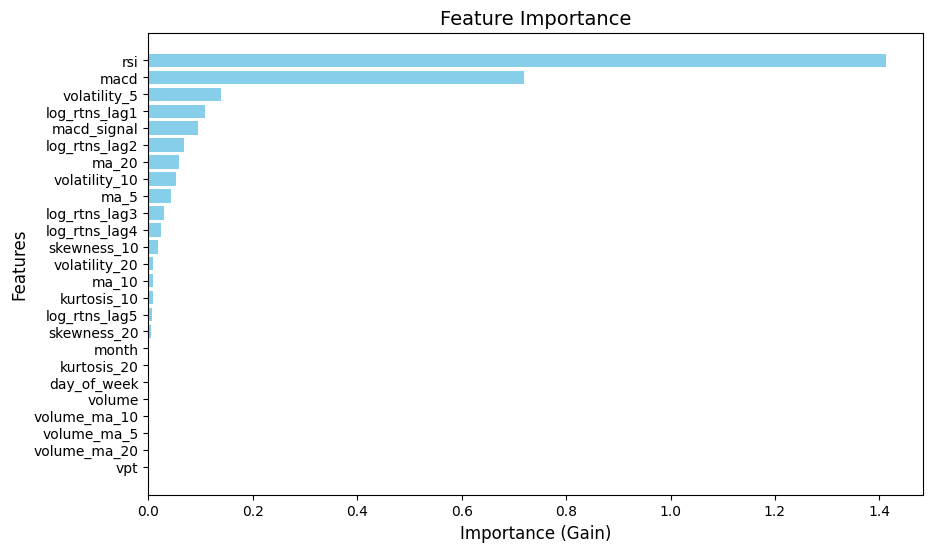

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4610
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 20
[LightGBM] [Info] Start training from score 0.000262
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

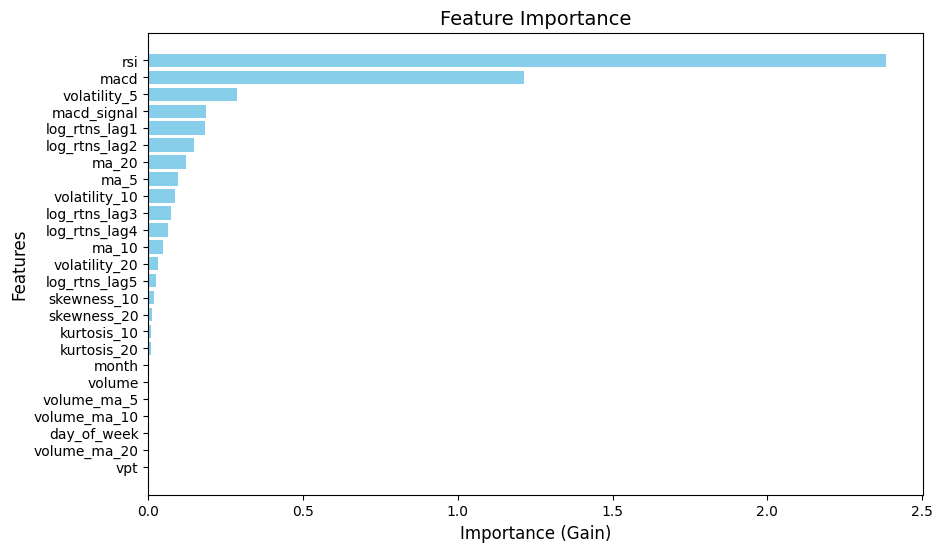

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000489 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4818
[LightGBM] [Info] Number of data points in the train set: 2013, number of used features: 25
[LightGBM] [Info] Start training from score 0.000378
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

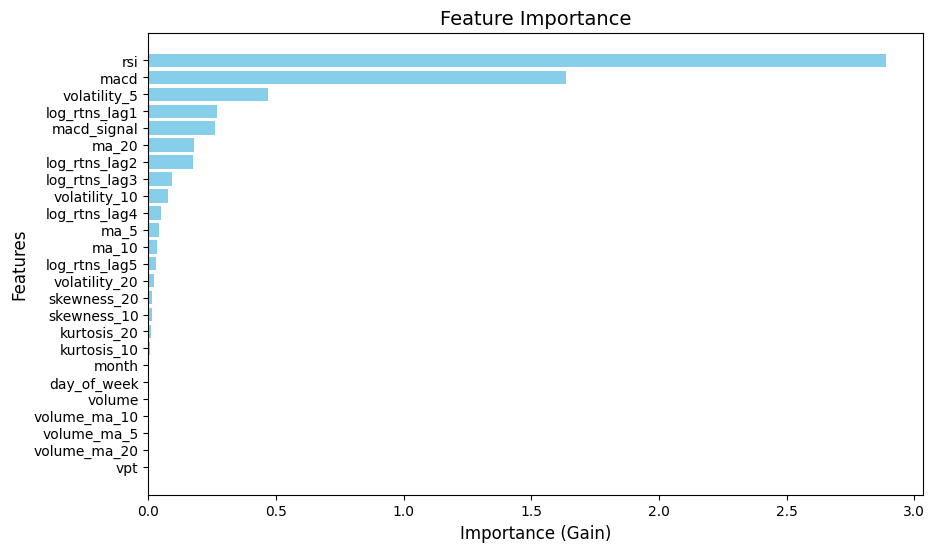

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000367 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5885
[LightGBM] [Info] Number of data points in the train set: 2683, number of used features: 25
[LightGBM] [Info] Start training from score 0.000435
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

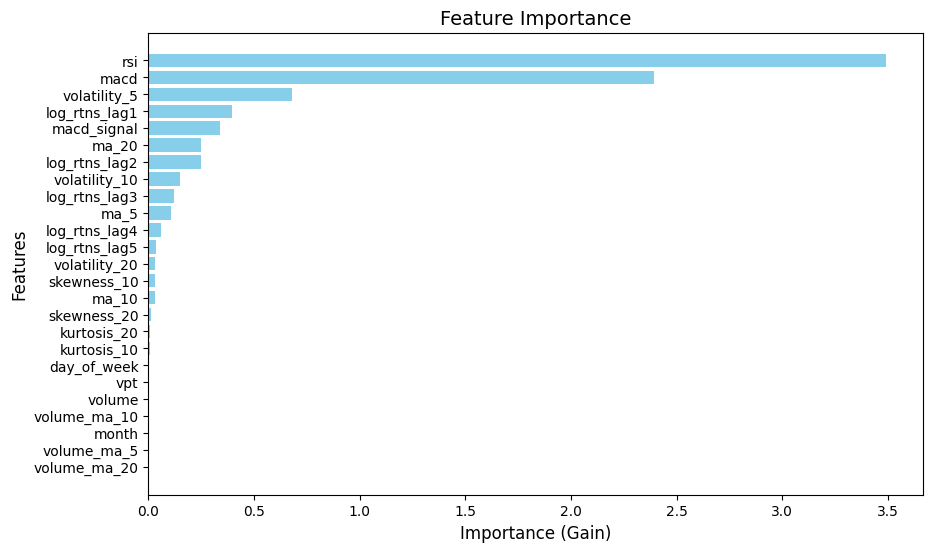

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5885
[LightGBM] [Info] Number of data points in the train set: 3353, number of used features: 25
[LightGBM] [Info] Start training from score 0.000395
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

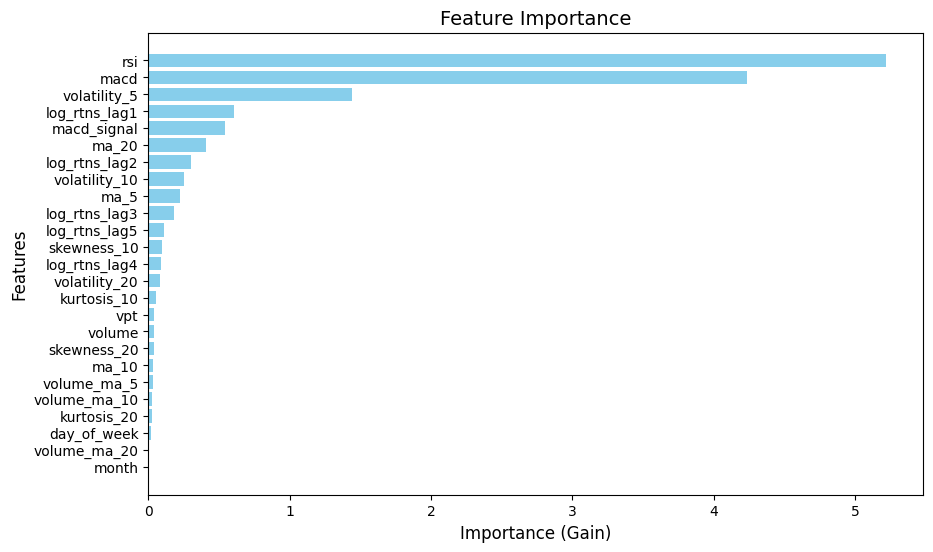

RMSE for each fold: [np.float64(0.006705000956614661), np.float64(0.006705000956614661), np.float64(0.003566810997504183), np.float64(0.005541953532647289), np.float64(0.016429058671923128), np.float64(0.005462314687188969), np.float64(0.006938993350304137), np.float64(0.004120815865760889), np.float64(0.005951151223281348), np.float64(0.016784938111937205), np.float64(0.006018377343151244)]
Mean RMSE: 0.0076567650633570655


In [32]:
import matplotlib.pyplot as plt

# Train model
for train_idx, test_idx in tscv.split(X):
    train_X, test_X = X.iloc[train_idx], X.iloc[test_idx]
    train_y, test_y = y.iloc[train_idx], y.iloc[test_idx]

    # Train GBM model
    model = train_gbm(train_X, train_y, test_X, test_y)

    # Predict and calculate error
    predictions = model.predict(test_X)
    rmse = np.sqrt(mean_squared_error(test_y, predictions))
    errors.append(rmse)

    # Plot feature importance
    plot_feature_importance(model, train_X.columns)

# Print error estimates
print("RMSE по фолдам:", errors)
print("Среднее RMSE:", np.mean(errors))

## Support Vector Regression  (SVR)



Advantages:
- SVR эффективен на малых выборках и подходит для финансовых данных с небольшим числом признаков.
Handles nonlinearity: With kernels, SVM can model complex, nonlinear relationships in log returns.
-Robustness to noise: SVM focuses on finding the optimal hyperplane, which reduces the impact of outliers and noise.

Limitations:
- Computational cost increases for large datasets.
- Sensitive to hyperparameters like kernel choice, 𝐶 (regularization), and
𝛾 (for RBF kernels).






In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [34]:
df

,volume,log_rtns,log_rtns_lag1,log_rtns_lag2,log_rtns_lag3,log_rtns_lag4,log_rtns_lag5,ma_5,ma_10,ma_20,...,volume_ma_5,volume_ma_10,volume_ma_20,vpt,day_of_week,month,skewness_10,kurtosis_10,skewness_20,kurtosis_20
date,,,,,,,,,,,,,,,,,,,,,
2010-01-11,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,NaN,NaN,NaN
2010-01-12,0.000000e+00,-0.011917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN
2010-01-13,0.000000e+00,0.005129,-0.011917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000e+00,2,1,NaN,NaN,NaN,NaN
2010-01-14,0.000000e+00,0.014282,0.005129,-0.011917,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000e+00,3,1,NaN,NaN,NaN,NaN
2010-01-15,0.000000e+00,-0.002046,0.014282,0.005129,-0.011917,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,NaN,NaN,0.000000e+00,4,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-10,5.225669e+10,-0.003161,-0.003586,-0.000621,-0.014213,-0.003537,0.006334,-0.005023,-0.002341,0.000372,...,5.438799e+10,6.741623e+10,5.808137e+10,-8.788892e+10,1,2,-0.563911,1.177085,-0.050476,0.618679
2026-02-11,7.070704e+10,0.014872,-0.003161,-0.003586,-0.000621,-0.014213,-0.003537,-0.001342,-0.001091,0.001008,...,5.518836e+10,6.861967e+10,5.886901e+10,-8.805409e+10,2,2,0.612248,1.340705,0.177056,0.208381
2026-02-12,4.471251e+10,0.002865,0.014872,-0.003161,-0.003586,-0.000621,-0.014213,0.002074,-0.001154,0.001177,...,5.100445e+10,5.876126e+10,5.940536e+10,-8.700252e+10,3,2,0.641377,1.472914,0.098446,0.187481


In [35]:
# Feature selection
X = data.drop(columns=["log_rtns"]).values
y = data["log_rtns"].values

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

In [37]:
# Initialize SVR with RBF kernel
svr = SVR(kernel='rbf', C=1.0, gamma='scale')

# Train the model
svr.fit(X_train, y_train)

# Make predictions
y_pred = svr.predict(X_test)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"SVR RMSE: {rmse:.4f}")

SVR RMSE: 0.0542


Support Vector Regression (SVR) does not have built-in feature importance measures like tree-based models (e.g., LightGBM, Random Forest) because it operates on a kernel-based optimization process.

Permutation importance measures the impact of each feature by shuffling its values and observing the effect on model performance.







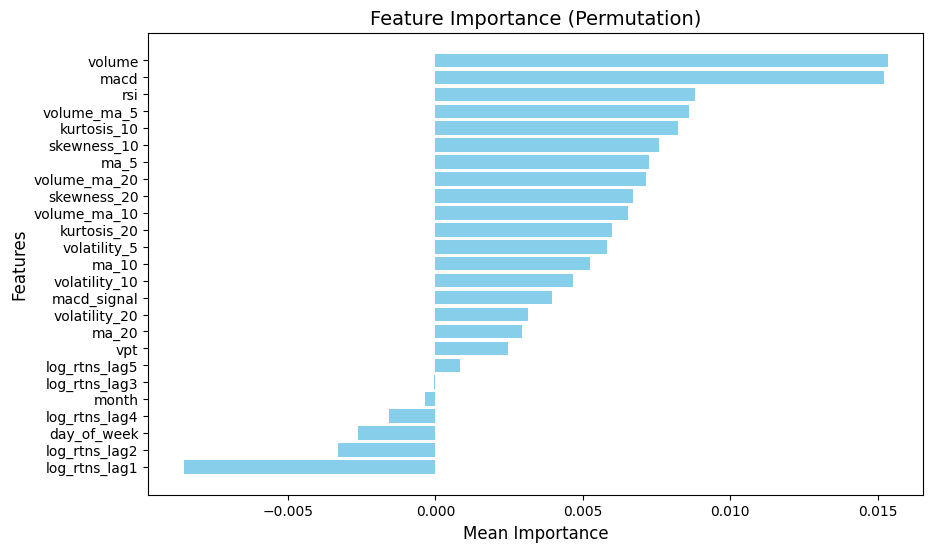

In [39]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Compute permutation importance
perm_importance = permutation_importance(svr, X_test, y_test, n_repeats=10, random_state=42)

# Extract feature importance and feature names
importance = perm_importance.importances_mean
feature_names = data.drop(columns=["log_rtns"]).columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="skyblue")
plt.xlabel("Mean Importance", fontsize=12)
plt.ylabel("Признаки", fontsize=12)
plt.title("Важность признаков (Permutation)", fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()


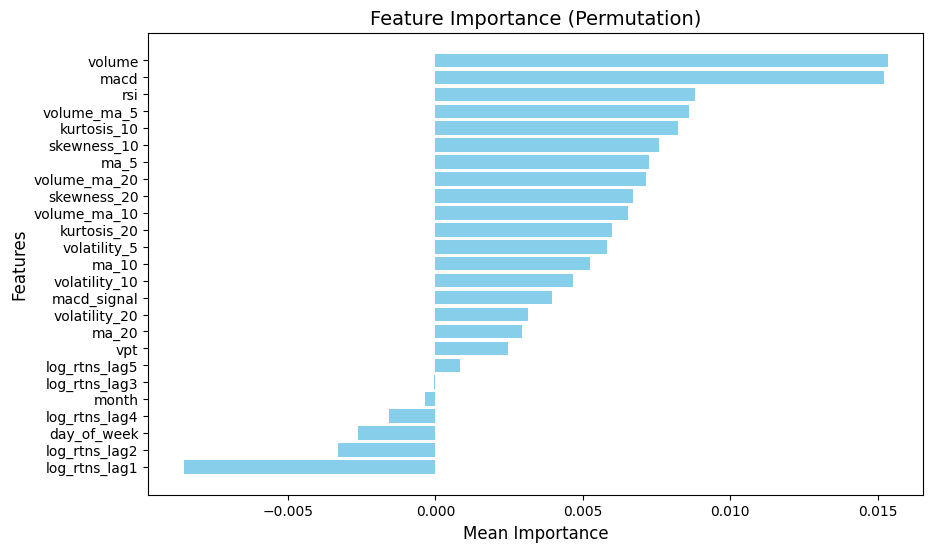

In [40]:
from sklearn.inspection import permutation_importance

# Compute permutation importance
perm_importance = permutation_importance(svr, X_test, y_test, n_repeats=10, random_state=42)

# Extract feature importance and feature names
importance = perm_importance.importances_mean
feature_names = data.drop(columns=["log_rtns"]).columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="skyblue")
plt.xlabel("Mean Importance", fontsize=12)
plt.ylabel("Признаки", fontsize=12)
plt.title("Важность признаков (Permutation)", fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()


## Neural nets - Recurrent Neural Networks (RNN) and others

Neural networks are powerful for capturing nonlinearities and temporal dependencies.

Log returns exhibit properties such as:

- Nonlinear patterns.
- Volatility clustering.
- Dependencies on external factors (e.g., macroeconomic indicators).

Neural networks are advantageous because they:

- Handle nonlinearity effectively.
- Learn complex temporal dependencies without requiring manual feature engineering.
- Incorporate exogenous variables (e.g., volume, sentiment) seamlessly.






In [41]:
#!pip install pmdarima

In [44]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima
import matplotlib.pyplot as plt


In [72]:
# Нормализация признаков: dropna(), чтобы в тензорах не было NaN (иначе loss станет NaN)
df = df.dropna()
scaler = MinMaxScaler()
features = df.columns.tolist()
df[features] = scaler.fit_transform(df[features])

C:\Users\m_salihov\AppData\Local\Temp\ipykernel_259764\3922558639.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[features] = scaler.fit_transform(df[features])


In [73]:
df 

,volume,log_rtns,log_rtns_lag1,log_rtns_lag2,log_rtns_lag3,log_rtns_lag4,log_rtns_lag5,ma_5,ma_10,ma_20,...,volume_ma_5,volume_ma_10,volume_ma_20,vpt,day_of_week,month,skewness_10,kurtosis_10,skewness_20,kurtosis_20
date,,,,,,,,,,,,,,,,,,,,,
2010-02-08,0.000000,0.646449,0.639256,0.646632,0.682459,0.712476,0.686143,0.651415,0.622561,0.568370,...,0.000000,0.000000,0.000000,0.801068,0.000000,0.090909,0.488507,0.024445,0.579904,0.009928
2010-02-09,0.000000,0.709553,0.646449,0.639256,0.646632,0.682459,0.712476,0.649191,0.664925,0.602215,...,0.000000,0.000000,0.000000,0.801068,0.166667,0.090909,0.406738,0.069890,0.553210,0.010141
2010-02-10,0.000000,0.675093,0.709553,0.646449,0.639256,0.646632,0.682459,0.643585,0.649017,0.583392,...,0.000000,0.000000,0.000000,0.801068,0.333333,0.090909,0.449271,0.057418,0.573201,0.009027
2010-02-11,0.000000,0.691759,0.675093,0.709553,0.646449,0.639256,0.646632,0.677931,0.635625,0.565466,...,0.000000,0.000000,0.000000,0.801068,0.500000,0.090909,0.453523,0.073186,0.574869,0.015197
2010-02-12,0.000000,0.657387,0.691759,0.675093,0.709553,0.646449,0.639256,0.691730,0.601166,0.542089,...,0.000000,0.000000,0.000000,0.801068,0.666667,0.090909,0.529530,0.071487,0.598179,0.005221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-10,0.103384,0.683668,0.682944,0.687993,0.664849,0.683026,0.699834,0.708656,0.676347,0.701892,...,0.165538,0.259614,0.291697,0.369429,0.166667,0.090909,0.421784,0.293834,0.602533,0.118376
2026-02-11,0.139886,0.714373,0.683668,0.682944,0.687993,0.664849,0.683026,0.732513,0.691811,0.719881,...,0.167974,0.264248,0.295652,0.368618,0.333333,0.090909,0.623743,0.307987,0.638136,0.095549
2026-02-12,0.088459,0.693928,0.714373,0.683668,0.682944,0.687993,0.664849,0.754645,0.691035,0.724644,...,0.155240,0.226284,0.298346,0.373782,0.500000,0.090909,0.628744,0.319422,0.625835,0.094386


In [ ]:
# Разбиение данных
train_data = df[df.index < '2024-01-01']  # Обучающая выборка до 2024
val_data = df[(df.index > '2024-01-01')&(df.index < '2025-01-01')] # 2024 - валидация
test_data = df[df.index  > '2024-01-01']  # Тестовая выборка после 2024

train_size = len(train_data)
val_size = len(val_data)
test_size = len(test_data)

In [75]:
# Prepare Tensors for LSTM
def prepare_lstm_data(data, target_col, feature_cols, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[feature_cols].iloc[i:i + seq_length].values)
        y.append(data[target_col].iloc[i + seq_length])
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

feature_cols = features
X_train, y_train = prepare_lstm_data(train_data, "log_rtns", feature_cols)
X_val, y_val = prepare_lstm_data(val_data, "log_rtns", feature_cols)
X_test, y_test = prepare_lstm_data(test_data, "log_rtns", feature_cols)

In [76]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        return out

# Initialize Model
input_dim = len(feature_cols)
hidden_dim = 64
num_layers = 2
output_dim = 1

model = LSTMModel(input_dim, hidden_dim, num_layers, output_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training Loop
epochs = 20
batch_size = 32
train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(list(zip(X_val, y_val)), batch_size=batch_size, shuffle=False)

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch).squeeze()
        loss = criterion(y_pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    # Validation Loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch).squeeze()
            val_loss += criterion(y_pred, y_batch).item()

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(val_loader):.4f}")


Epoch 1/20, Train Loss: 0.0305, Val Loss: 0.0009
Epoch 2/20, Train Loss: 0.0008, Val Loss: 0.0009
Epoch 3/20, Train Loss: 0.0008, Val Loss: 0.0006
Epoch 4/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 5/20, Train Loss: 0.0007, Val Loss: 0.0007
Epoch 6/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 7/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 8/20, Train Loss: 0.0007, Val Loss: 0.0007
Epoch 9/20, Train Loss: 0.0007, Val Loss: 0.0007
Epoch 10/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 11/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 12/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 13/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 14/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 15/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 16/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 17/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 18/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 19/20, Train Loss: 0.0007, Val Loss: 0.0006
Epoch 20/20, Train Loss: 0.0007, Val Loss: 0.0006


In [77]:
# Train AutoARIMA
auto_arima_model = auto_arima(train_data["log_rtns"], seasonal=False, trace=True)


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=1.49 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=7303.886, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2882.533, Time=0.26 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.95 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-564.827, Time=0.40 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-15537.749, Time=0.52 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-15481.667, Time=1.62 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-3012.813, Time=0.46 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-15512.550, Time=0.66 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-15552.220, Time=1.26 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=2.05 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=3.47 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=-15432.311, Time=2.19 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-1557

In [ ]:
# Прогнозы LSTM (already 1-step-ahead per test sample)
model.eval()
lstm_predictions = []
with torch.no_grad():
    for X in X_test:
        lstm_predictions.append(model(X.unsqueeze(0)).item())

# AutoARIMA: скользящий прогноз на 1 шаг вперёд (как у LSTM)
seq_length = 10  # должно совпадать с prepare_lstm_data
import copy
arima_1step = copy.deepcopy(auto_arima_model)
arima_forecast_1step = []
for i in range(len(test_data)):
    pred = arima_1step.predict(n_periods=1)
    arima_forecast_1step.append(pred[0])
    arima_1step.update(test_data["log_rtns"].iloc[i:i+1].values)
arima_forecast_1step = np.array(arima_forecast_1step[seq_length:])  # align with y_test

# Сравнение RMSE (same targets y_test, same horizon 1-step)
y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else np.array(y_test)
lstm_rmse = np.sqrt(mean_squared_error(y_test_np, lstm_predictions))
arima_rmse = np.sqrt(mean_squared_error(y_test_np, arima_forecast_1step))

print(f"LSTM RMSE (1 шаг): {lstm_rmse:.4f}")
print(f"AutoARIMA RMSE (1 шаг): {arima_rmse:.4f}")


C:\Users\m_salihov\AppData\Local\Temp\ipykernel_259764\3940122373.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  arima_forecast_1step.append(pred[0])


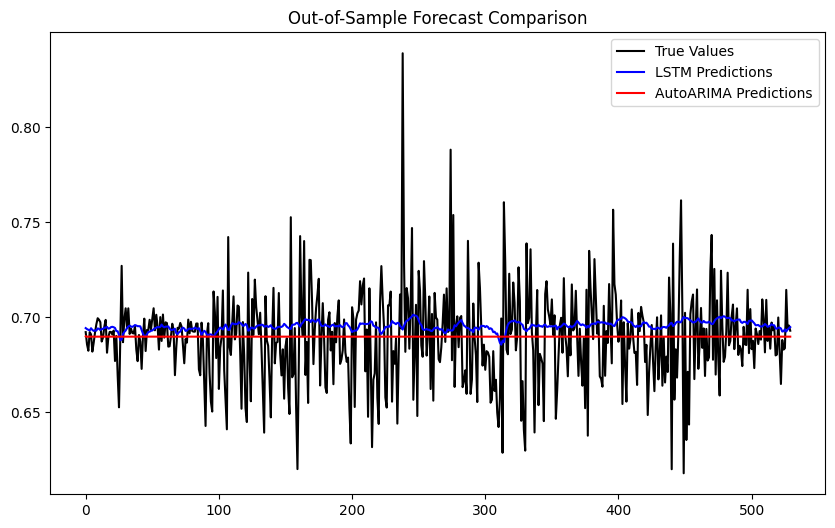

In [79]:
# Одинаковая длина для фактических значений и прогнозов
test_len = min(len(y_test), len(lstm_predictions), len(arima_forecast_1step))

# Обрезка по минимальной длине
true_values = y_test_np[:test_len]
lstm_plot = lstm_predictions[:test_len]
arima_plot = arima_forecast_1step[:test_len]

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(range(test_len), true_values, label="Фактические значения", color="black")
plt.plot(range(test_len), lstm_plot, label="LSTM (1 шаг)", color="blue")
plt.plot(range(test_len), arima_plot, label="AutoARIMA (1 шаг)", color="red")
plt.legend()
plt.title("Сравнение прогнозов вне выборки")
plt.show()
